In [58]:
# %%
# cluster.py

In [59]:
# %%
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_openml, load_breast_cancer
from sklearn.decomposition import PCA, FastICA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.random_projection import GaussianRandomProjection

sns.set_theme(style="whitegrid")
os.makedirs("./result", exist_ok=True)

In [60]:
# %%
# Load the Yeast dataset
yeast_data = fetch_openml(data_id=181, as_frame=True)
yeast_df = yeast_data.frame
yeast_df["target"] = yeast_data.target

# Identify categorical columns
categorical_columns = yeast_df.select_dtypes(include=["category"]).columns

# One-hot encode categorical columns
yeast_features = pd.get_dummies(yeast_df, columns=categorical_columns, drop_first=True)

# Separate features and target
yeast_target = yeast_df["target"]

In [61]:
# %%
# Load the Breast Cancer dataset (keeping this for comparison)
bc_data = load_breast_cancer()
bc_df = pd.DataFrame(bc_data.data, columns=bc_data.feature_names)
bc_df["target"] = bc_data.target

In [62]:
# %%
def tsne_visualization_2d(data, labels, title, filename):
    tsne = TSNE(n_components=2, random_state=42)
    tsne_result = tsne.fit_transform(data)

    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        x=tsne_result[:, 0],
        y=tsne_result[:, 1],
        hue=labels,
        palette="viridis",
        legend="full",
        s=60,
        alpha=0.7,
        edgecolor=None,
    )
    plt.title(title, fontsize=16)
    plt.xticks([])
    plt.yticks([])
    plt.xlabel("")
    plt.ylabel("")
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)
    plt.savefig(f"./result/{filename}")
    plt.show()

In [63]:
# %%
def apply_clustering(data, n_clusters):
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans_labels = kmeans.fit_predict(scaled_data)

    em = GaussianMixture(n_components=n_clusters, random_state=42)
    em_labels = em.fit_predict(scaled_data)

    return kmeans_labels, em_labels

In [64]:
# %%
# Apply clustering to Yeast dataset
yeast_kmeans_labels, yeast_em_labels = apply_clustering(yeast_features, n_clusters=10)

# Apply clustering to Breast Cancer dataset
bc_kmeans_labels, bc_em_labels = apply_clustering(
    bc_df[bc_data.feature_names], n_clusters=2
)

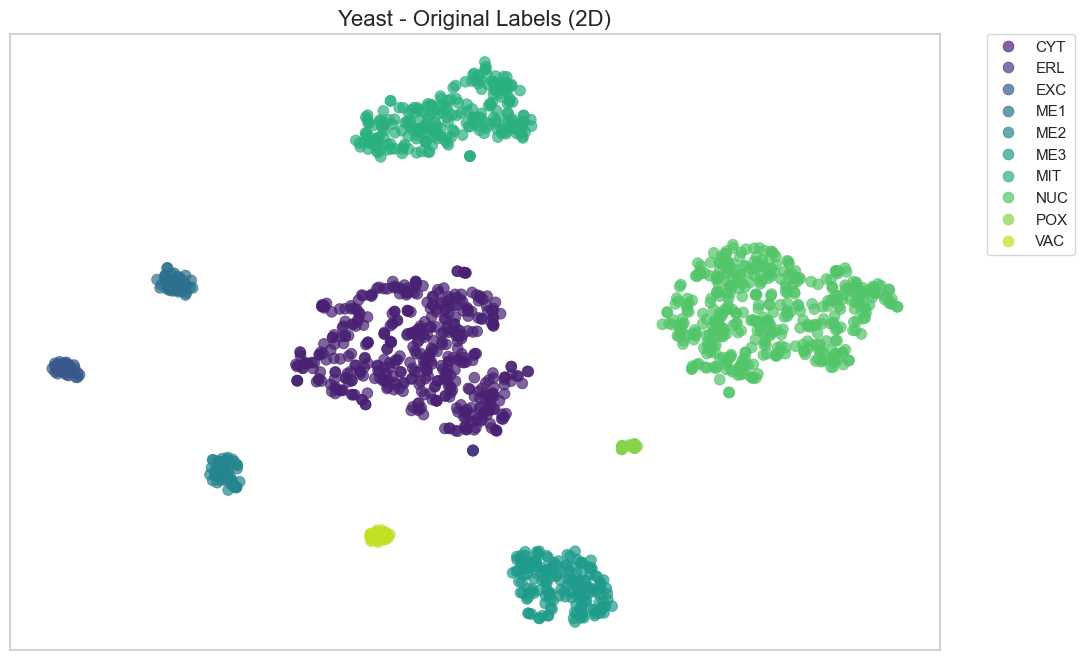

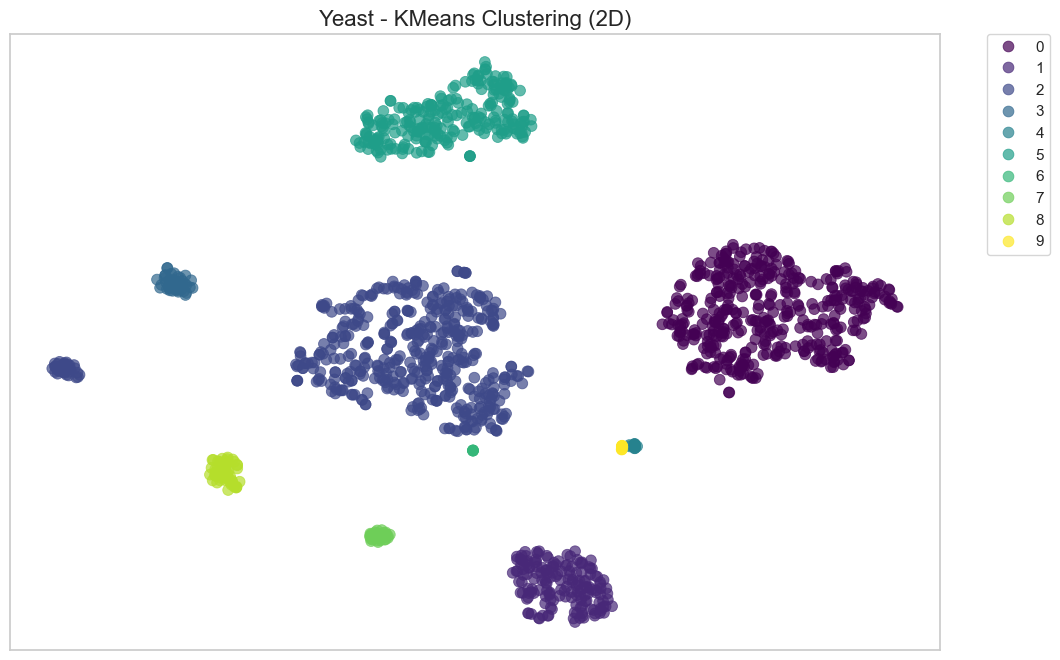

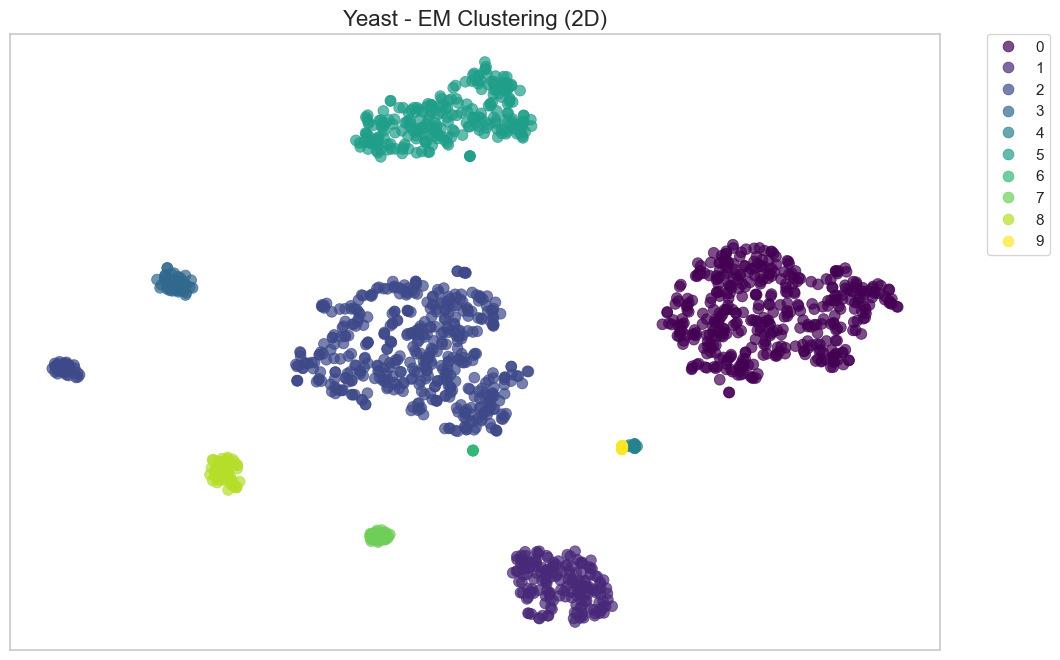

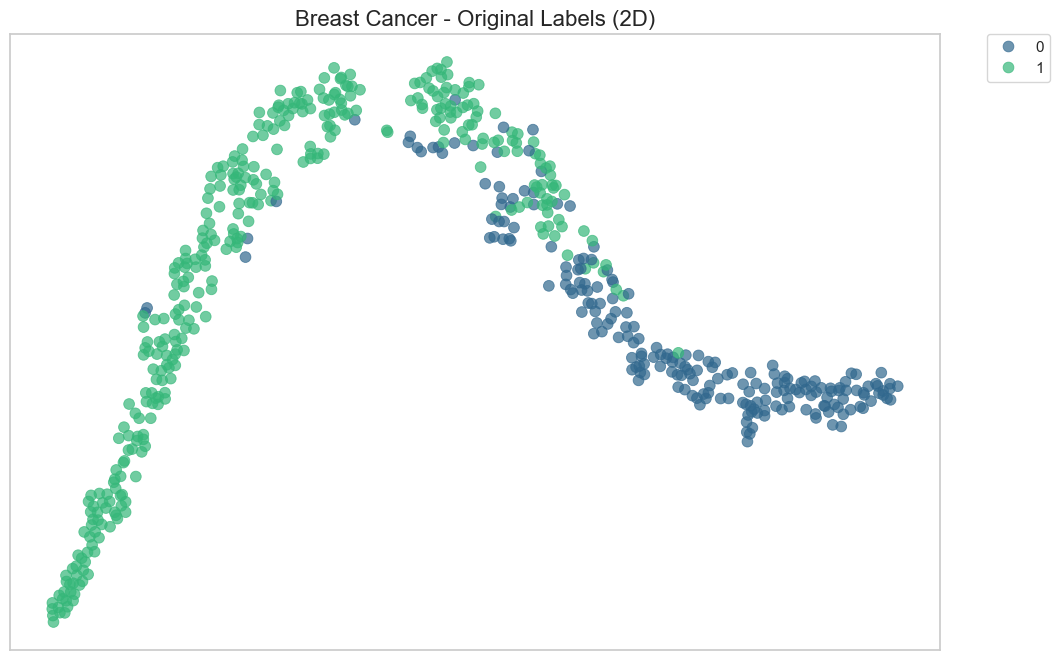

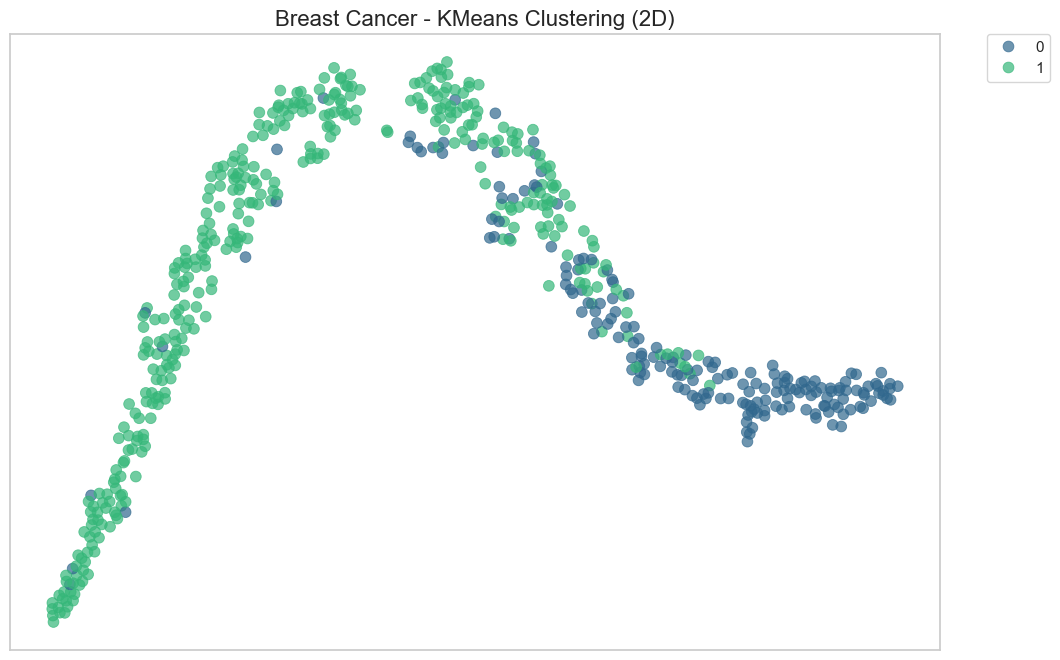

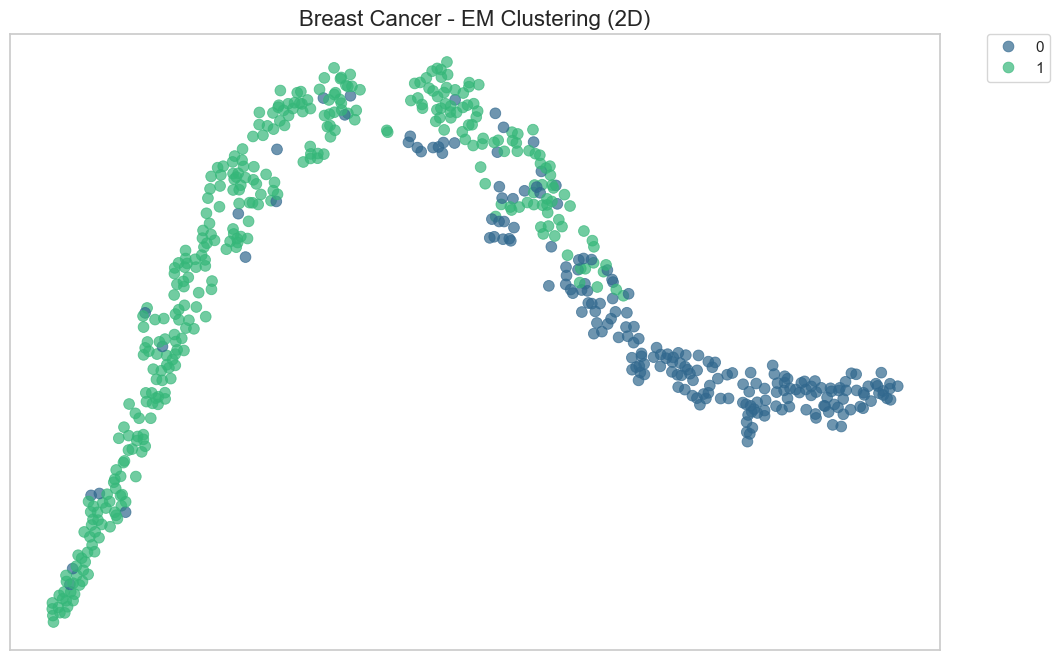

In [65]:
# %%
# Visualizations for Yeast dataset
tsne_visualization_2d(
    yeast_features,
    yeast_df["target"],
    "Yeast - Original Labels (2D)",
    "yeast_original_labels.png",
)
tsne_visualization_2d(
    yeast_features,
    yeast_kmeans_labels,
    "Yeast - KMeans Clustering (2D)",
    "yeast_kmeans_clustering.png",
)
tsne_visualization_2d(
    yeast_features,
    yeast_em_labels,
    "Yeast - EM Clustering (2D)",
    "yeast_em_clustering.png",
)

# Visualizations for Breast Cancer dataset (keeping this for comparison)
tsne_visualization_2d(
    bc_df[bc_data.feature_names],
    bc_df["target"],
    "Breast Cancer - Original Labels (2D)",
    "bc_original_labels.png",
)
tsne_visualization_2d(
    bc_df[bc_data.feature_names],
    bc_kmeans_labels,
    "Breast Cancer - KMeans Clustering (2D)",
    "bc_kmeans_clustering.png",
)
tsne_visualization_2d(
    bc_df[bc_data.feature_names],
    bc_em_labels,
    "Breast Cancer - EM Clustering (2D)",
    "bc_em_clustering.png",
)

In [66]:
# %%
def evaluate_clustering_performance(true_labels, pred_labels):
    return adjusted_rand_score(true_labels, pred_labels), normalized_mutual_info_score(
        true_labels, pred_labels
    )


yeast_kmeans_ari, yeast_kmeans_nmi = evaluate_clustering_performance(
    yeast_df["target"], yeast_kmeans_labels
)
yeast_em_ari, yeast_em_nmi = evaluate_clustering_performance(
    yeast_df["target"], yeast_em_labels
)

bc_kmeans_ari, bc_kmeans_nmi = evaluate_clustering_performance(
    bc_df["target"], bc_kmeans_labels
)
bc_em_ari, bc_em_nmi = evaluate_clustering_performance(bc_df["target"], bc_em_labels)

In [67]:
# %%
pca = PCA(n_components=2)
yeast_pca = pca.fit_transform(yeast_features)
bc_pca = pca.fit_transform(bc_df[bc_data.feature_names])

ica = FastICA(n_components=2, random_state=42)
yeast_ica = ica.fit_transform(yeast_features)
bc_ica = ica.fit_transform(bc_df[bc_data.feature_names])

rp = GaussianRandomProjection(n_components=2, random_state=42)
yeast_rp = rp.fit_transform(yeast_features)
bc_rp = rp.fit_transform(bc_df[bc_data.feature_names])

yeast_pca_kmeans_labels, yeast_pca_em_labels = apply_clustering(
    yeast_pca, n_clusters=10
)
yeast_ica_kmeans_labels, yeast_ica_em_labels = apply_clustering(
    yeast_ica, n_clusters=10
)
yeast_rp_kmeans_labels, yeast_rp_em_labels = apply_clustering(yeast_rp, n_clusters=10)

bc_pca_kmeans_labels, bc_pca_em_labels = apply_clustering(bc_pca, n_clusters=2)
bc_ica_kmeans_labels, bc_ica_em_labels = apply_clustering(bc_ica, n_clusters=2)
bc_rp_kmeans_labels, bc_rp_em_labels = apply_clustering(bc_rp, n_clusters=2)

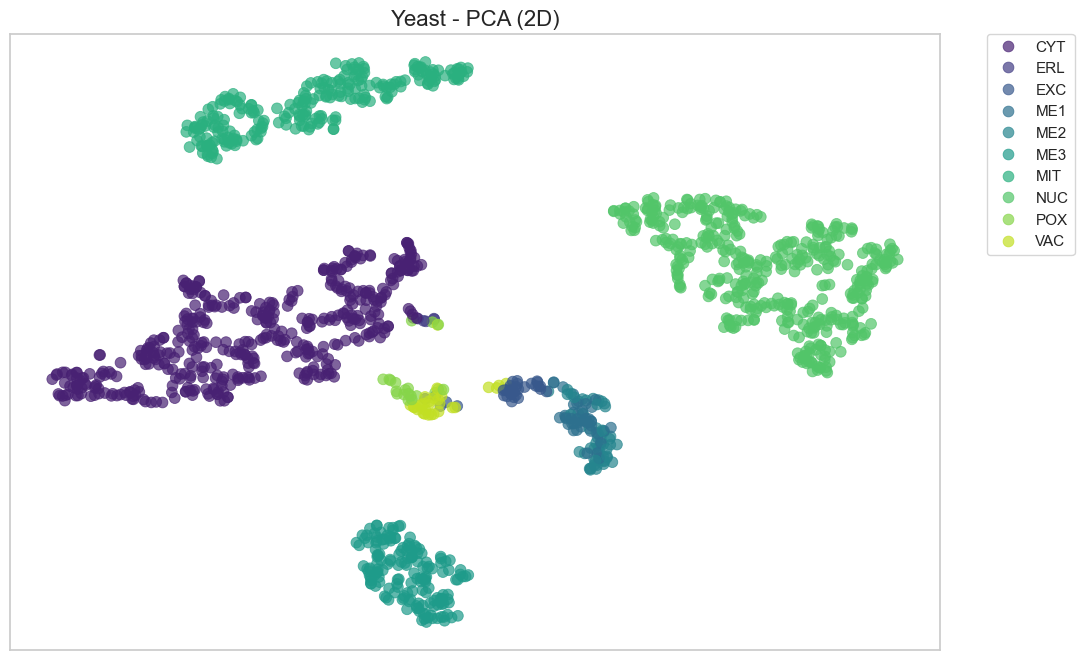

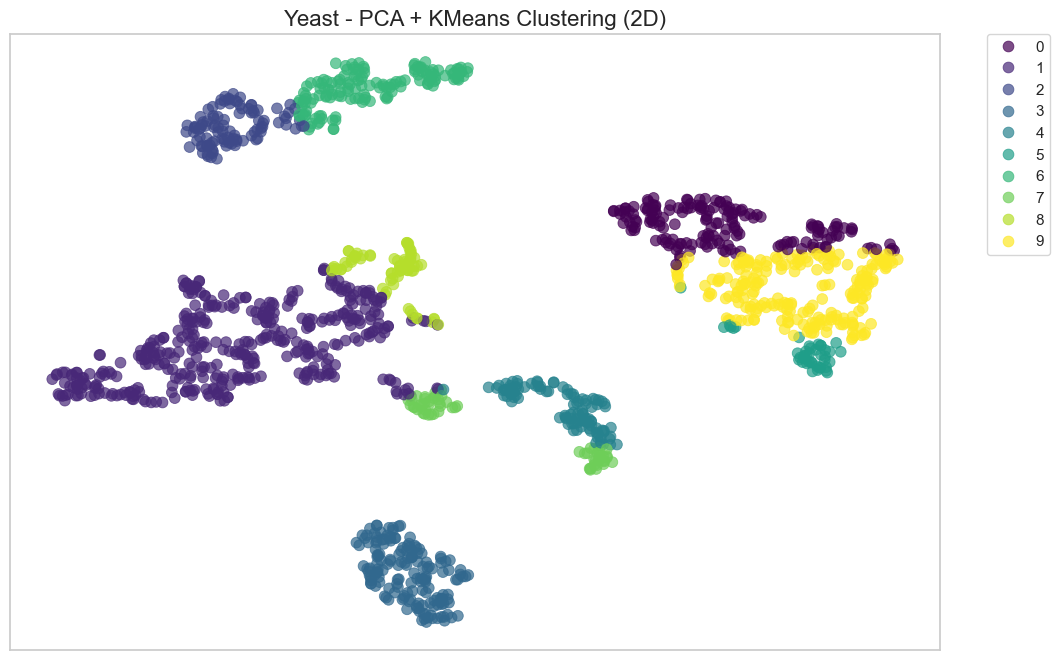

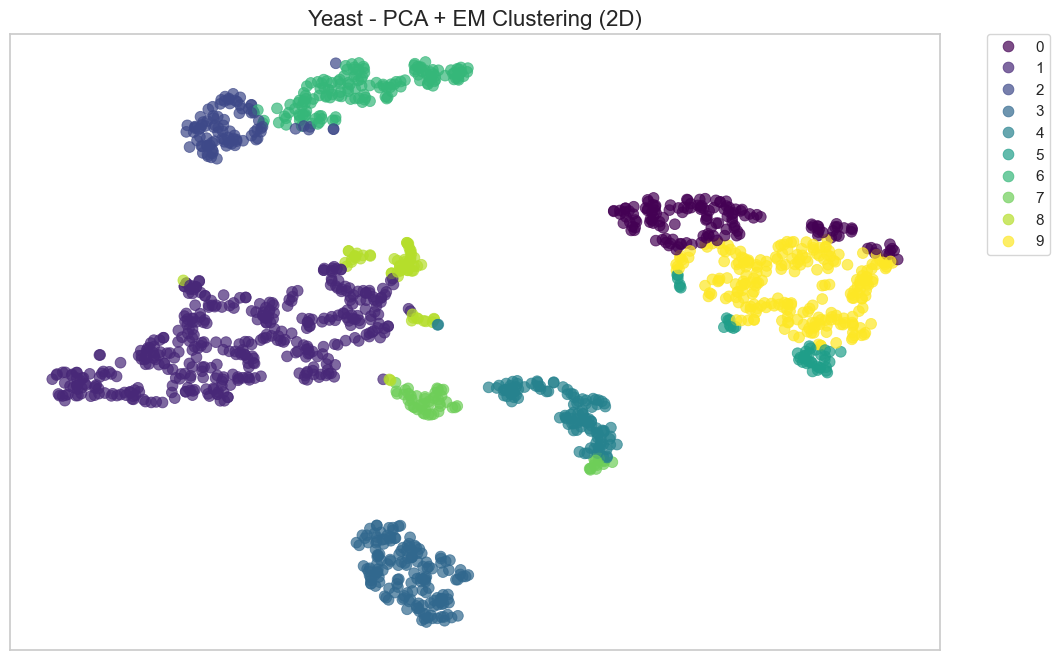

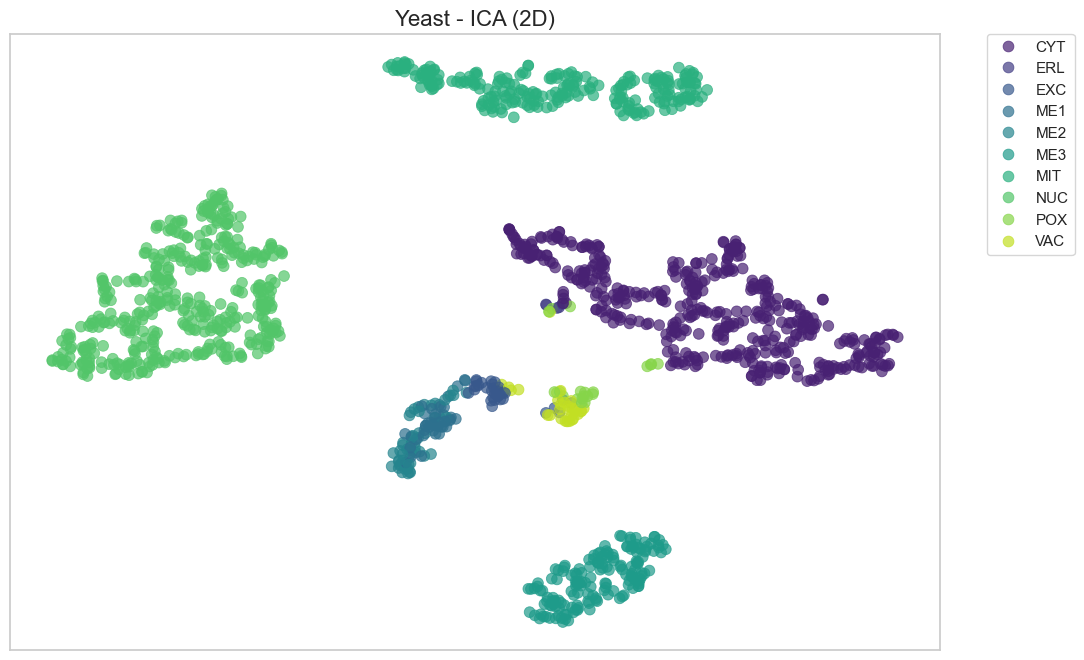

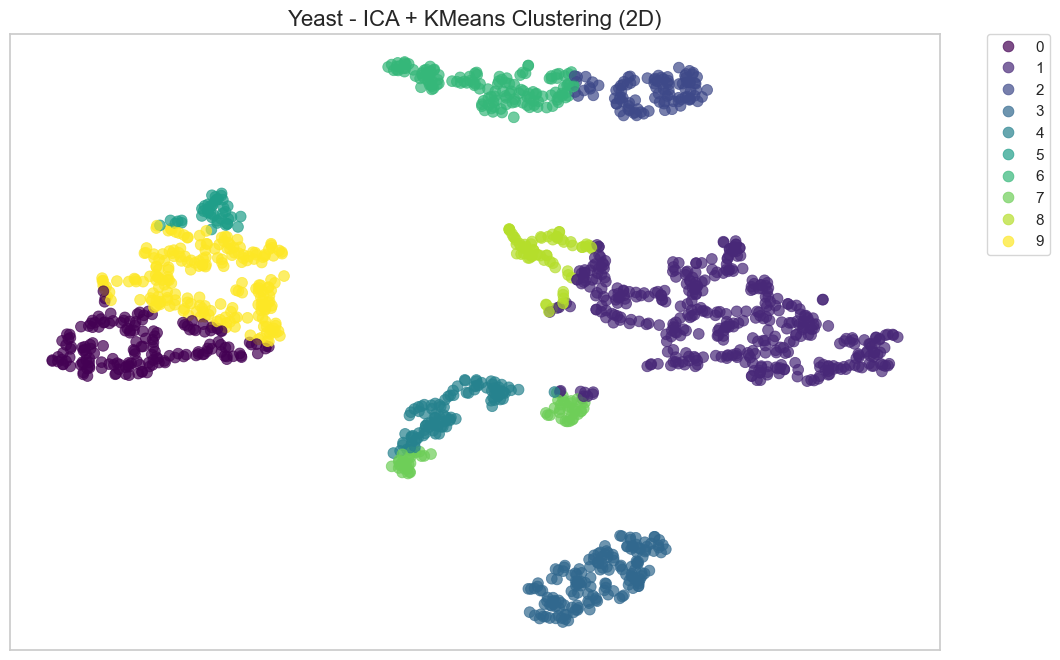

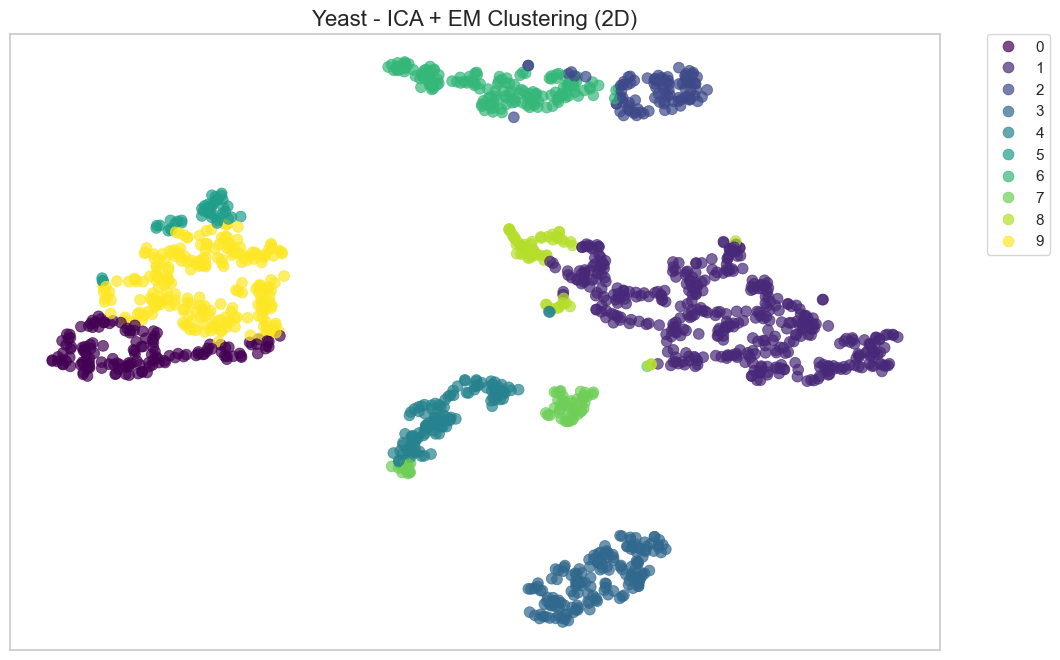

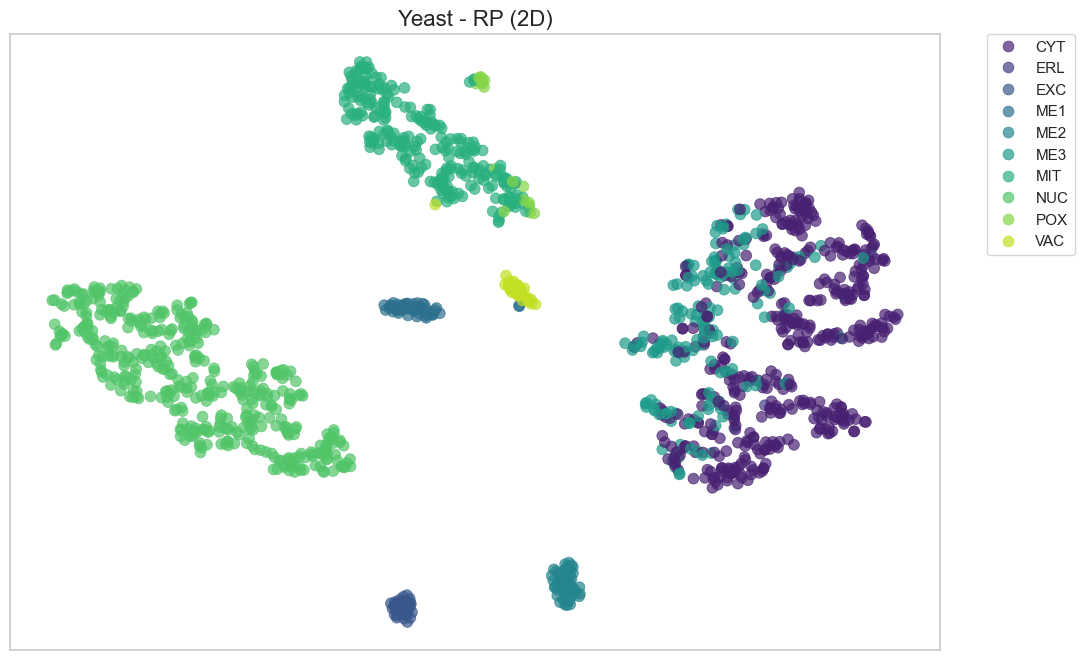

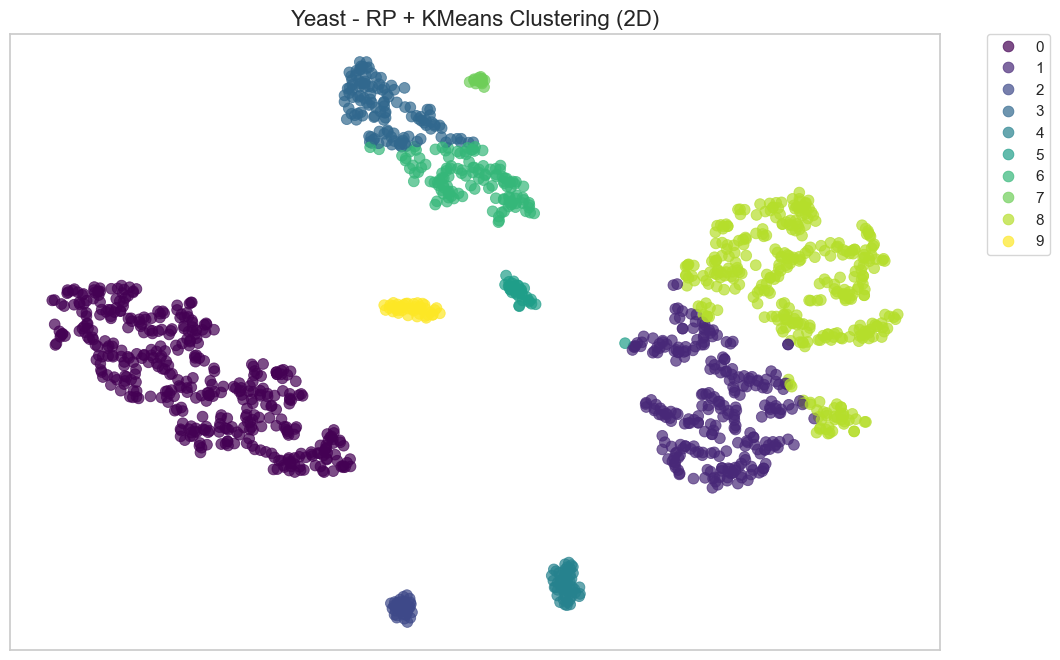

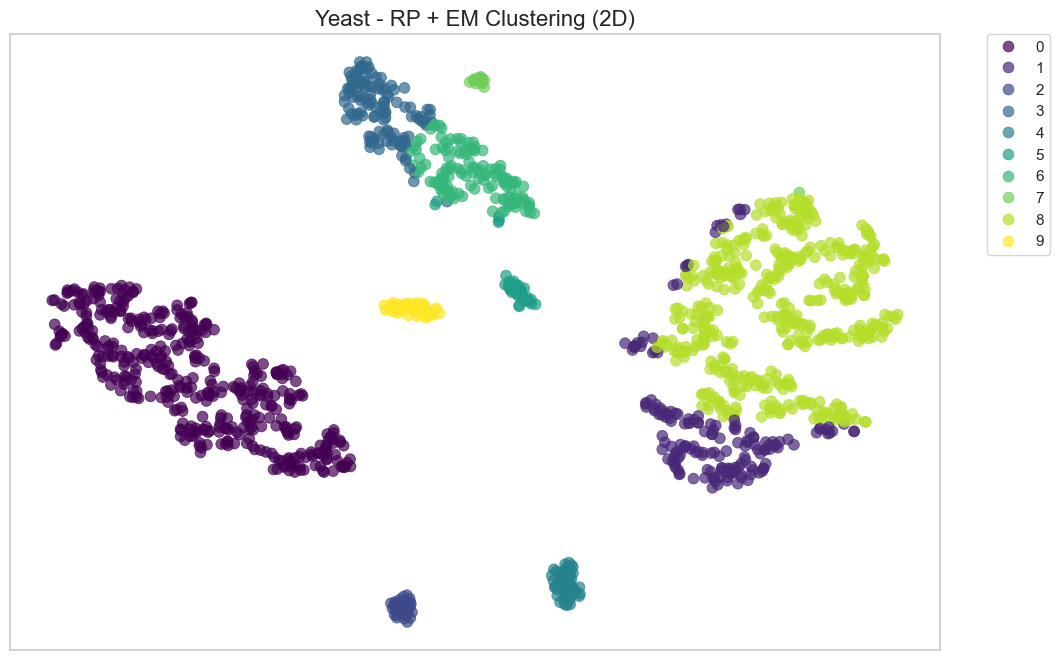

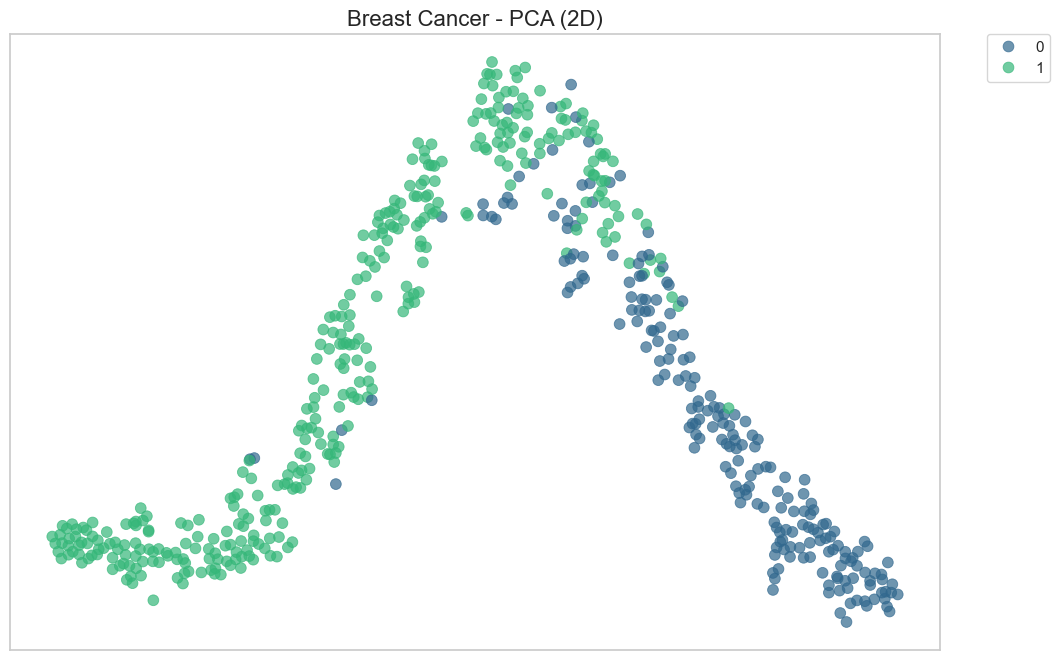

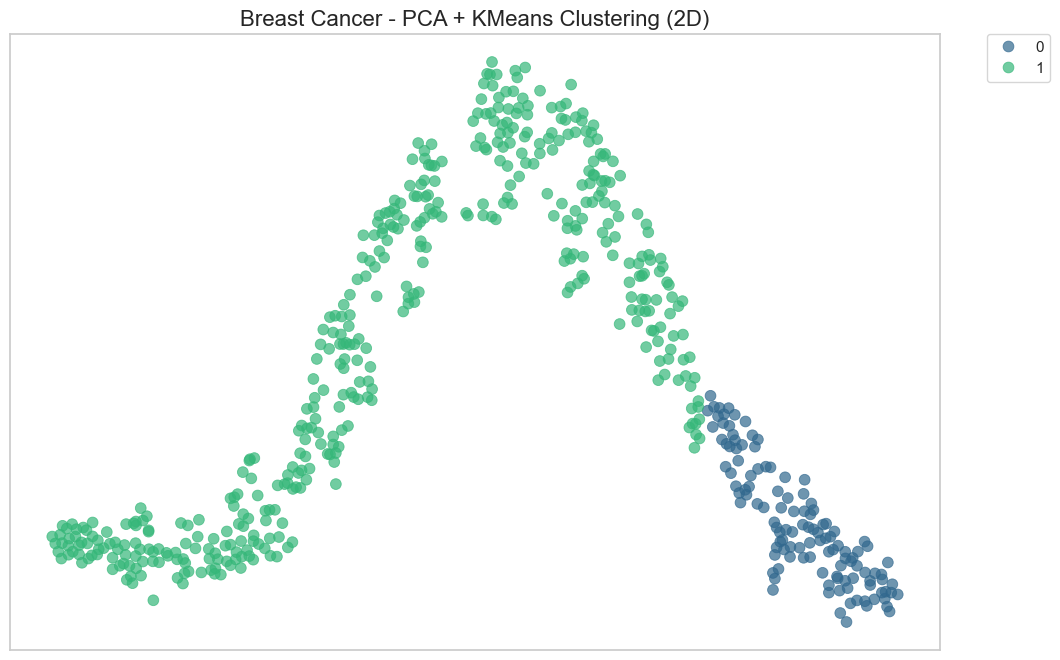

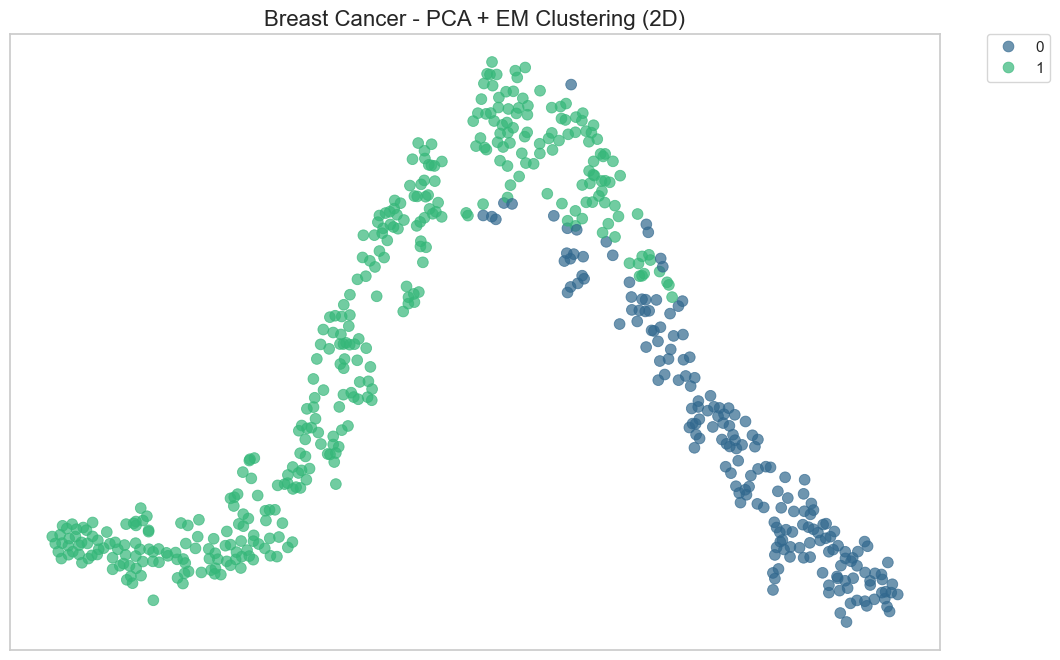

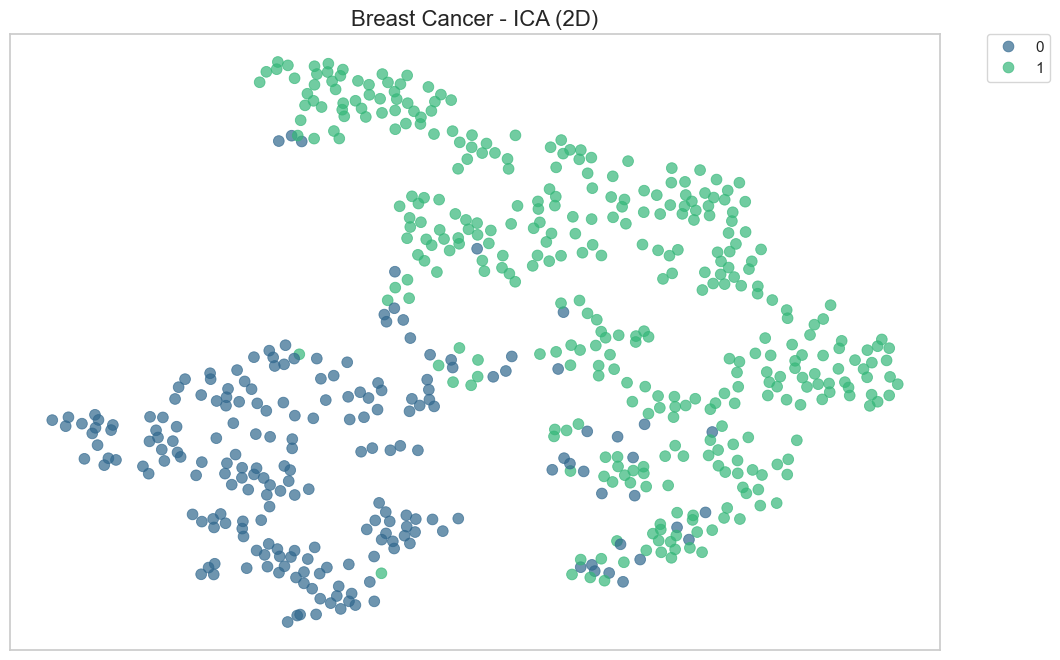

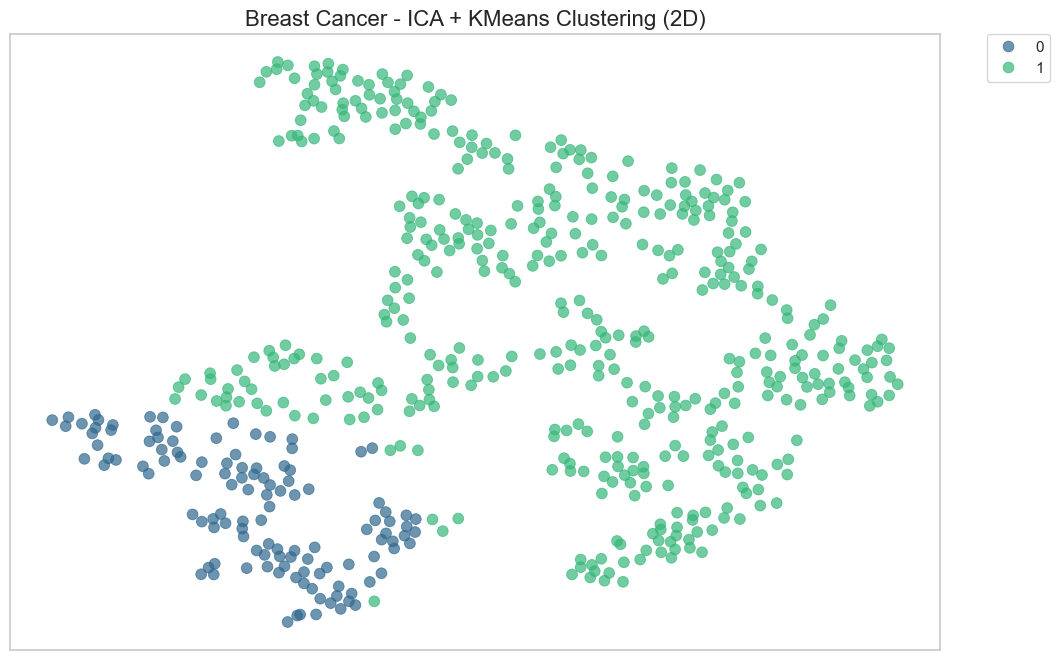

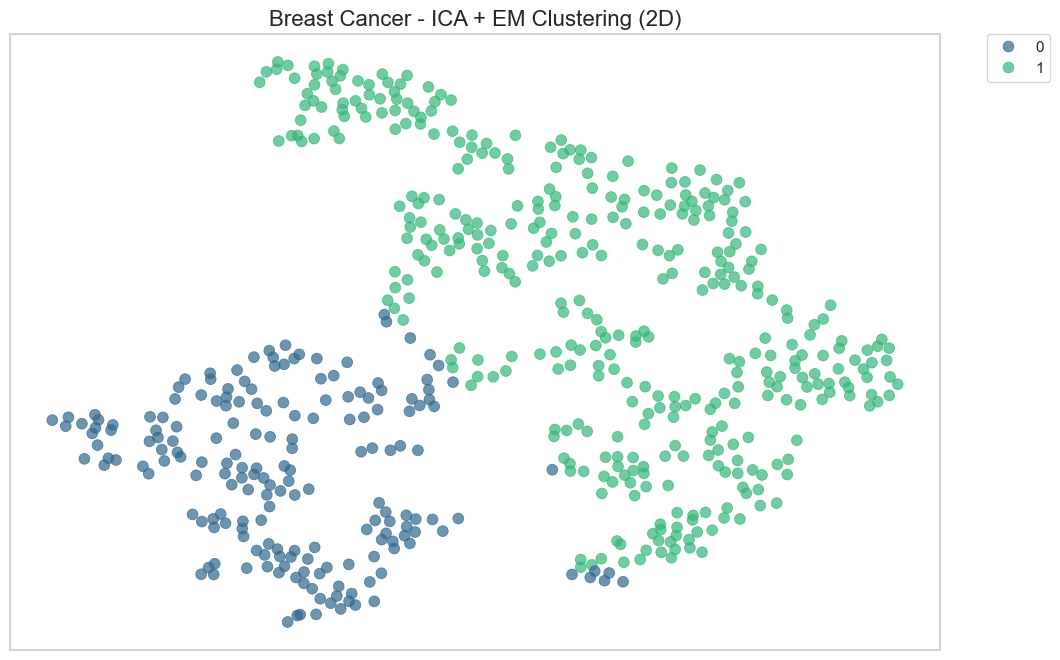

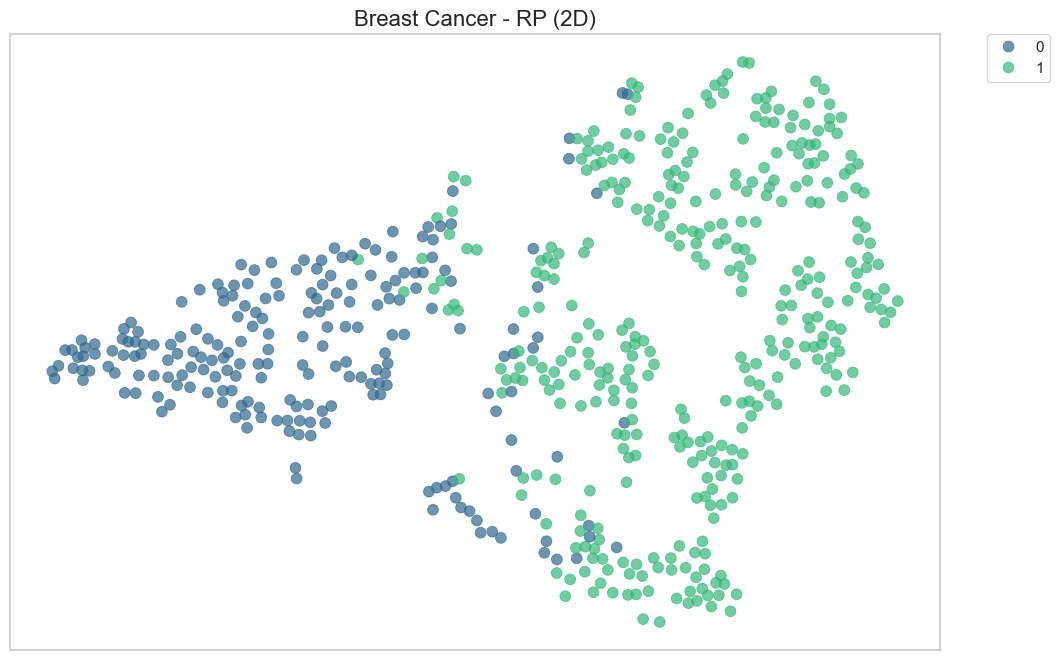

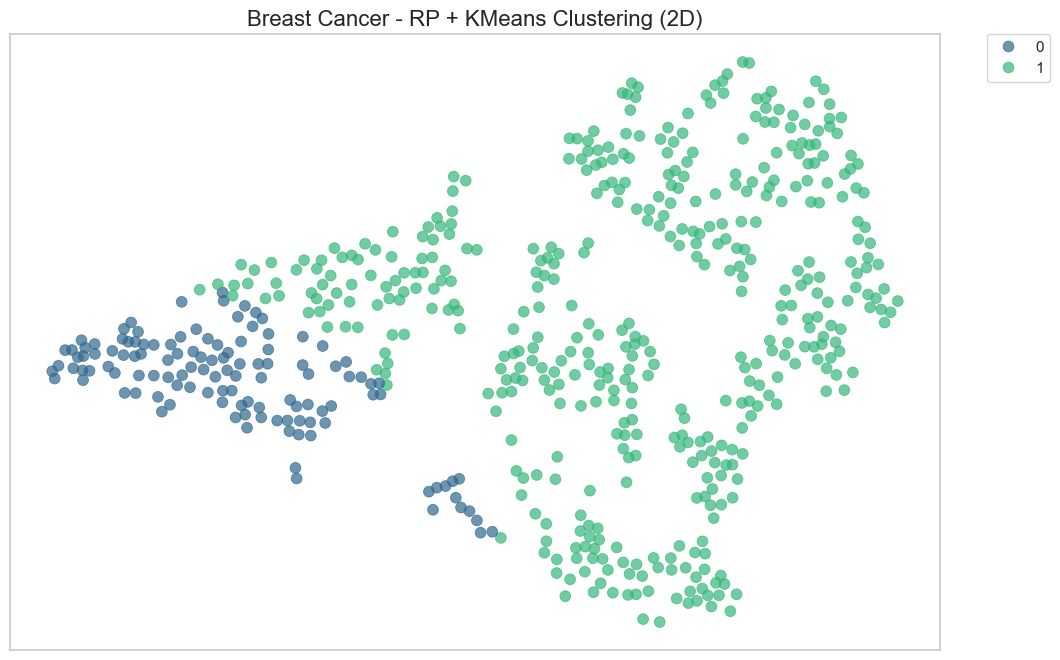

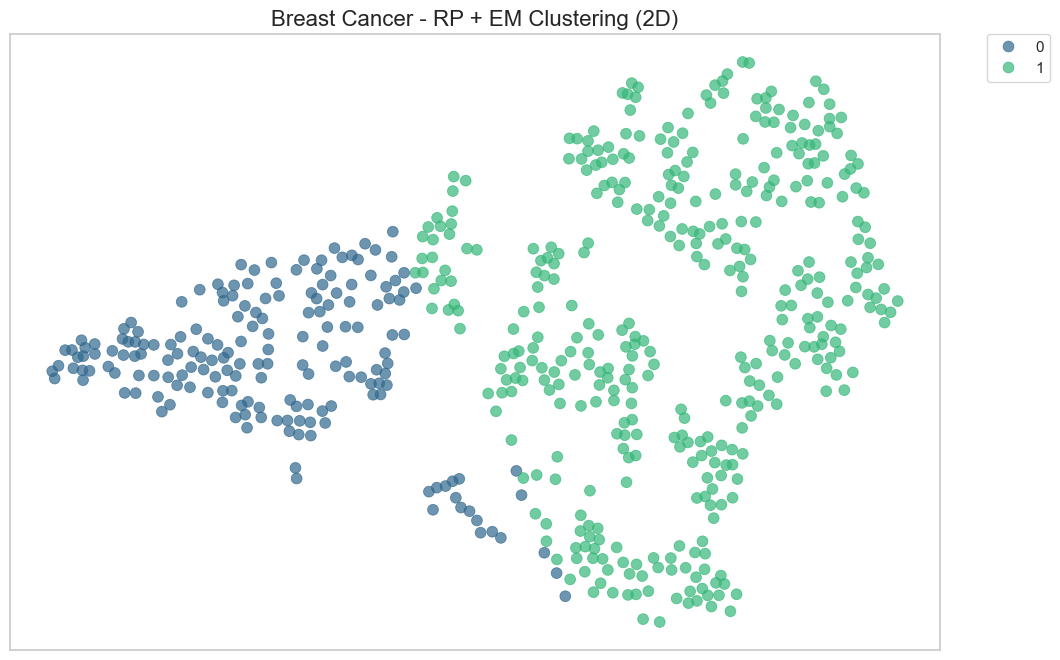

In [68]:
# %%
tsne_visualization_2d(
    yeast_pca, yeast_df["target"], "Yeast - PCA (2D)", "yeast_pca.png"
)
tsne_visualization_2d(
    yeast_pca,
    yeast_pca_kmeans_labels,
    "Yeast - PCA + KMeans Clustering (2D)",
    "yeast_pca_kmeans_clustering.png",
)
tsne_visualization_2d(
    yeast_pca,
    yeast_pca_em_labels,
    "Yeast - PCA + EM Clustering (2D)",
    "yeast_pca_em_clustering.png",
)

tsne_visualization_2d(
    yeast_ica, yeast_df["target"], "Yeast - ICA (2D)", "yeast_ica.png"
)
tsne_visualization_2d(
    yeast_ica,
    yeast_ica_kmeans_labels,
    "Yeast - ICA + KMeans Clustering (2D)",
    "yeast_ica_kmeans_clustering.png",
)
tsne_visualization_2d(
    yeast_ica,
    yeast_ica_em_labels,
    "Yeast - ICA + EM Clustering (2D)",
    "yeast_ica_em_clustering.png",
)

tsne_visualization_2d(yeast_rp, yeast_df["target"], "Yeast - RP (2D)", "yeast_rp.png")
tsne_visualization_2d(
    yeast_rp,
    yeast_rp_kmeans_labels,
    "Yeast - RP + KMeans Clustering (2D)",
    "yeast_rp_kmeans_clustering.png",
)
tsne_visualization_2d(
    yeast_rp,
    yeast_rp_em_labels,
    "Yeast - RP + EM Clustering (2D)",
    "yeast_rp_em_clustering.png",
)

tsne_visualization_2d(bc_pca, bc_df["target"], "Breast Cancer - PCA (2D)", "bc_pca.png")
tsne_visualization_2d(
    bc_pca,
    bc_pca_kmeans_labels,
    "Breast Cancer - PCA + KMeans Clustering (2D)",
    "bc_pca_kmeans_clustering.png",
)
tsne_visualization_2d(
    bc_pca,
    bc_pca_em_labels,
    "Breast Cancer - PCA + EM Clustering (2D)",
    "bc_pca_em_clustering.png",
)

tsne_visualization_2d(bc_ica, bc_df["target"], "Breast Cancer - ICA (2D)", "bc_ica.png")
tsne_visualization_2d(
    bc_ica,
    bc_ica_kmeans_labels,
    "Breast Cancer - ICA + KMeans Clustering (2D)",
    "bc_ica_kmeans_clustering.png",
)
tsne_visualization_2d(
    bc_ica,
    bc_ica_em_labels,
    "Breast Cancer - ICA + EM Clustering (2D)",
    "bc_ica_em_clustering.png",
)

tsne_visualization_2d(bc_rp, bc_df["target"], "Breast Cancer - RP (2D)", "bc_rp.png")
tsne_visualization_2d(
    bc_rp,
    bc_rp_kmeans_labels,
    "Breast Cancer - RP + KMeans Clustering (2D)",
    "bc_rp_kmeans_clustering.png",
)
tsne_visualization_2d(
    bc_rp,
    bc_rp_em_labels,
    "Breast Cancer - RP + EM Clustering (2D)",
    "bc_rp_em_clustering.png",
)

In [69]:
# %%
yeast_pca_kmeans_ari, yeast_pca_kmeans_nmi = evaluate_clustering_performance(
    yeast_df["target"], yeast_pca_kmeans_labels
)
yeast_pca_em_ari, yeast_pca_em_nmi = evaluate_clustering_performance(
    yeast_df["target"], yeast_pca_em_labels
)
yeast_ica_kmeans_ari, yeast_ica_kmeans_nmi = evaluate_clustering_performance(
    yeast_df["target"], yeast_ica_kmeans_labels
)
yeast_ica_em_ari, yeast_ica_em_nmi = evaluate_clustering_performance(
    yeast_df["target"], yeast_ica_em_labels
)
yeast_rp_kmeans_ari, yeast_rp_kmeans_nmi = evaluate_clustering_performance(
    yeast_df["target"], yeast_rp_kmeans_labels
)
yeast_rp_em_ari, yeast_rp_em_nmi = evaluate_clustering_performance(
    yeast_df["target"], yeast_rp_em_labels
)

bc_pca_kmeans_ari, bc_pca_kmeans_nmi = evaluate_clustering_performance(
    bc_df["target"], bc_pca_kmeans_labels
)
bc_pca_em_ari, bc_pca_em_nmi = evaluate_clustering_performance(
    bc_df["target"], bc_pca_em_labels
)
bc_ica_kmeans_ari, bc_ica_kmeans_nmi = evaluate_clustering_performance(
    bc_df["target"], bc_ica_kmeans_labels
)
bc_ica_em_ari, bc_ica_em_nmi = evaluate_clustering_performance(
    bc_df["target"], bc_ica_em_labels
)
bc_rp_kmeans_ari, bc_rp_kmeans_nmi = evaluate_clustering_performance(
    bc_df["target"], bc_rp_kmeans_labels
)
bc_rp_em_ari, bc_rp_em_nmi = evaluate_clustering_performance(
    bc_df["target"], bc_rp_em_labels
)

In [74]:
# %%
results_df = pd.DataFrame(
    {
        "Dataset": ["Yeast"] * 8 + ["Breast Cancer"] * 8,
        "Algorithm": [
            "KMeans",
            "EM",
            "PCA + KMeans",
            "PCA + EM",
            "ICA + KMeans",
            "ICA + EM",
            "RP + KMeans",
            "RP + EM",
        ]
        * 2,
        "ARI": [
            yeast_kmeans_ari,
            yeast_em_ari,
            yeast_pca_kmeans_ari,
            yeast_pca_em_ari,
            yeast_ica_kmeans_ari,
            yeast_ica_em_ari,
            yeast_rp_kmeans_ari,
            yeast_rp_em_ari,
            bc_kmeans_ari,
            bc_em_ari,
            bc_pca_kmeans_ari,
            bc_pca_em_ari,
            bc_ica_kmeans_ari,
            bc_ica_em_ari,
            bc_rp_kmeans_ari,
            bc_rp_em_ari,
        ],
        "NMI": [
            yeast_kmeans_nmi,
            yeast_em_nmi,
            yeast_pca_kmeans_nmi,
            yeast_pca_em_nmi,
            yeast_ica_kmeans_nmi,
            yeast_ica_em_nmi,
            yeast_rp_kmeans_nmi,
            yeast_rp_em_nmi,
            bc_kmeans_nmi,
            bc_em_nmi,
            bc_pca_kmeans_nmi,
            bc_pca_em_nmi,
            bc_ica_kmeans_nmi,
            bc_ica_em_nmi,
            bc_rp_kmeans_nmi,
            bc_rp_em_nmi,
        ],
    }
)


def highlight_max(data, color="yellow"):
    attr = "background-color: {}".format(color)
    is_max = data == data.max()
    return [attr if v else "" for v in is_max]


results_df.style.apply(highlight_max, subset=["ARI", "NMI"], axis=0).set_table_styles(
    [dict(selector="th", props=[("text-align", "center")])]
).set_properties(**{"text-align": "center"}).set_caption(
    "Clustering Performance Comparison"
).format(
    {"ARI": "{:.3f}", "NMI": "{:.3f}"}
).hide(
    axis="index"
)

Dataset,Algorithm,ARI,NMI
Yeast,KMeans,0.958,0.972
Yeast,EM,0.958,0.972
Yeast,PCA + KMeans,0.683,0.794
Yeast,PCA + EM,0.718,0.812
Yeast,ICA + KMeans,0.683,0.794
Yeast,ICA + EM,0.718,0.812
Yeast,RP + KMeans,0.689,0.798
Yeast,RP + EM,0.703,0.802
Breast Cancer,KMeans,0.677,0.562
Breast Cancer,EM,0.774,0.661


In [ ]:
# %%